# CLASSIFICATIONS PROBABILISTES

Le but de ce projet est d'étudier les méthodes de classifications auxquelles les statistiques donnent accès naturellement. Il s'agira donc d'étudier les outils de classifications probabilistes. C'est bien évidemment une petite partie de l'ensemble des méthodes de classification existant.


In [3]:
%load_ext autoreload
%autoreload 2

import pandas as pd # package for high-performance, easy-to-use data structures and data analysis
import numpy as np # fundamental package for scientific computing with Python
  
# utils.py contient des fonctions et des classes d'aide au tme10. IL NE FAUT RIEN CHANGER DANS CE FICHIER
# liste des classes et fonctions de ce fichier :
#  - getNthDict (remplit un dictionnaire avec la ligne n d'un dataframe)
#  - viewData (visualisation d'un dataframe)
#  - discretizeData (discrétisation automatique)
#  - AbstractClassifier (classe abstraite pour tous les classifieurs)
#  - drawGraphHorizontal (dessin d'un graphe orienté horizontal)
#  - drawGraph (dessin d'un graphe orienté vertical)
import utils

import tme10

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
train=pd.read_csv("data/train.csv")
test=pd.read_csv("data/test.csv")

## 7- Sophistication du modèle (question BONUS)

La semaine dernière, nous avons étudier des classifieurs Naivex Bayes qui utilisnt un arbre pour représenter la factorisation de la loi jointe. C'est bien sûr une simplification : beaucoup de distribution ne peuvent pas être représentées avec un seul parent par variable.

Un modèle plus sophisitiqué existe donc : le TAN (Tree-augmented Naïve Bayes). Il consiste à rajouter au plus un parent à chaque attribut parmi les autres attributs (sans créer de cycle). En plus des arcs les reliant à la classe, un TABN induit donc un arbre (plus exactement une forêt) parmi les attributs.

Ci-dessous un TAN dont la classe est $T$.

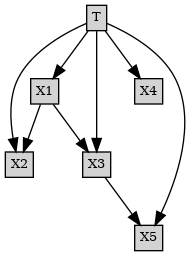

In [5]:
utils.drawGraph("T->X1;T->X2;T->X3;T->X4;T->X5;X1->X2;X1->X3;X3->X5")

et dont l'arbre (la forêt) sur les attributs est bien :

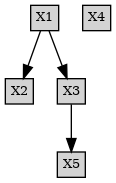

In [6]:
utils.drawGraph("X1->X2;X1->X3;X3->X5;X4")

L'algorithme pour générer cette structure se base sur une autre façon de tester l'indépendance entre deux variables aléatoires : l'information mutuelle qui calcule une distance entre la distribution des 2 variables et la distribution si ces 2 variables étaient indépendantes (voir https://fr.wikipedia.org/wiki/Information_mutuelle). Pour construire l'arbre (la forêt) entre les attributs, sachant qu'on garde les arcs issus de la classe, il faut tester des indépendances conditionnelles et donc calculer des informations mutuelles conditionnelles (https://en.wikipedia.org/wiki/Conditional_mutual_information).

On gardera de ces pages les deux formules :
$$I(X;Y)=\sum_{x,y} P(x,y)\log_2\frac{P(x,y)}{P(x)P(y)}$$

$$I(X;Y|Z)=\sum_{z,x,y} P(x,y,z)\log_2\frac{P(z)P(x,y,z)}{P(x,z)P(y,z)}$$

Et on remarquera que :
- $P(x,z)=\sum_y P(x,y,z)$, 
- $P(y,z)=\sum_x P(x,y,z)$, 
- $P(z)=\sum_{x,y} P(x,y,z)$, 
- etc.

### Question 7.1 : calcul des informations mutuelles
Écrire des fonctions `tme10.MutualInformation(df,x,y)` et `tme10.ConditionalMutualInformation(df,x,y,z)` qui calcule ces informations mutuelles

In [7]:
for attr in train.keys():
    if attr!='target':
        print(f"target->{attr:10} : {tme10.MutualInformation(train,'target',attr):5.7f}")

AttributeError: module 'tme10' has no attribute 'MutualInformation'

(On retrouve au passage que `fbs` est très peu dépendantes de la classe ...)

On peut également calculer la matrice des informations mutuelles entre attributs, conditionnellement à `target`.

In [6]:
cmis=np.array([[0 if x==y else tme10.ConditionalMutualInformation(train,x,y,"target") 
                for x in train.keys() if x!="target"]
               for y in train.keys() if y!="target"])
cmis[0:5,0:5] # on affiche qu'une partie 5x5 de la matrice

array([[0.        , 0.07172827, 0.20250622, 0.6417183 , 0.55128095],
       [0.07172827, 0.        , 0.01672381, 0.06361231, 0.12140024],
       [0.20250622, 0.01672381, 0.        , 0.22413205, 0.18890573],
       [0.6417183 , 0.06361231, 0.22413205, 0.        , 0.68149423],
       [0.55128095, 0.12140024, 0.18890573, 0.68149423, 0.        ]])

(on remarque que, évidemment, la matrice `cmis` est symétrique)

### Question 7.2 : calcul de la matrice des poids
La matrice `cmis` calculé ci-dessus représente l'ensemble des arcs possibles entre les attributs et leur poids. Pour trouver un arbre dans ces arcs, on commence par simplifier cette matrice en supprimant les poids faibles. Par exemple, en retirant la moyenne.

Faites une fonction `tme10.MeanForSymetricWeights(a)` qui calcule la moyenne des poids pour une matrice `a` symétrique de diagonale nulle.

Puis écrire une fonction `tme10.simplifyContitionalMutualInformationMatrix(a)` qui annule toutes les valeurs plus petites que cette moyenne dans une matrice  `a` symétrique de diagonale nulle.

In [7]:
tme10.MeanForSymetricWeights(cmis)

0.14490408192274776

In [8]:
tme10.SimplifyConditionalMutualInformationMatrix(cmis)
cmis[0:5,0:5]

array([[0.        , 0.        , 0.20250622, 0.6417183 , 0.55128095],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.20250622, 0.        , 0.        , 0.22413205, 0.18890573],
       [0.6417183 , 0.        , 0.22413205, 0.        , 0.68149423],
       [0.55128095, 0.        , 0.18890573, 0.68149423, 0.        ]])

### Question 7.3 : Arbre (forêt) optimal entre les attributs

Un algorithme pour trouver un arbre de poids maximal est l'algorithm de Kruskal (https://fr.wikipedia.org/wiki/Algorithme_de_Kruskal). En se souvenant qu'on veut relier les attributs si ils sont très dépendants, écrire la fonction `tme10.Kruskal(df,a)` qui propose la liste des arcs (non orientés pour l'instant) à ajouter dans notre classifieur sous la forme d'une liste de triplet $(attr1,attr2,poids)$. 

<b>Remarque</b> : `df` ne sert ici qu'à retrouver le nom des attributs à partir de leur indice grâce à `train.keys()[i]`.

In [9]:
liste_arcs=tme10.Kruskal(train,cmis)
liste_arcs

[('trestbps', 'chol', np.float64(0.6814942282235203)),
 ('age', 'trestbps', np.float64(0.641718295908513)),
 ('age', 'thalach', np.float64(0.6365766485465845)),
 ('chol', 'oldpeak', np.float64(0.5246930555244587)),
 ('oldpeak', 'slope', np.float64(0.25839871090530614)),
 ('chol', 'ca', np.float64(0.2528327956181666))]

### Question 7.4: Orientation des arcs entre attributs.

Il s'agit maintenant d'orienter l'arbre (la forêt) entre les attributs. On choisit la (ou les) racine(s) en maximisant l'information mutuelle entre ces attributs et la classe (donc en utilisant `tme10.MutualInformation`.

Créer une fonction `tme10.ConnexSet(list_arcs)` qui rend une liste d'ensemble d'attributs connectés, 

In [10]:
# 3 arcs de poids quelconques dans le graphe a--b--c   d--e
tme10.ConnexSets([('a','b',0.878),
                   ('b','c',0.4568),
                   ('d','e',0.123156)])

[{'a', 'b', 'c'}, {'d', 'e'}]

In [11]:
tme10.ConnexSets(liste_arcs)

[{'age', 'ca', 'chol', 'oldpeak', 'slope', 'thalach', 'trestbps'}]

Puis écrire une fonction `tme10.OrientConnexSets(df,arcs,classe)` qui utilise l'information mutuelle (entre chaque attribut et la `classe`) pour proposer pour chaque ensemble d'attributs connexes une racine et qui rend la liste des arcs orientés.

In [12]:
tme10.OrientConnexSets(train,liste_arcs,'target')

[('ca', 'chol'),
 ('chol', 'trestbps'),
 ('trestbps', 'age'),
 ('age', 'thalach'),
 ('chol', 'oldpeak'),
 ('oldpeak', 'slope')]

Vous pouvez donc dessiner le graph représentant la factorisation obtenue: 

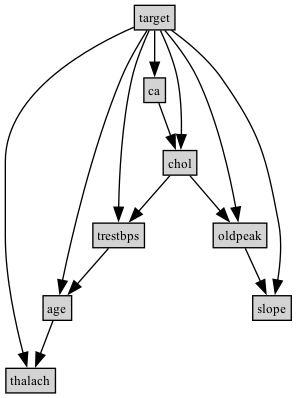

In [13]:
tme10.showTAN(train,liste_arcs)

### Question 7.5: Classifieur TAN
Écrire un `MAPTANClassifier(df)` qui construit un modèle TAN en suivant la procédure ci-dessus. Lui ajouter une procédure `Draw()`

**Note** : ici aussi, il faut faire descendre `MAPTANClassifier` de `APrioriClassifier` qu'il faut donc recopier dans `tme10.py` (depuis `tme8.py` ou `tme9.py`). 

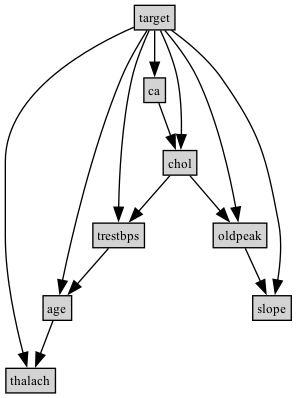

In [14]:
tan=tme10.MAPTANClassifier(train)
tan.draw()

In [15]:
for i in [0,1,2]:
    print(f"Estimation de la proba de l'individu {i} par ReducedMAPNaiveBayesClassifier : {tan.estimProbas(utils.getNthDict(train,i))}")
    print(f"Estimation de la classe de l'individu {i} par ReducedMAPNaiveBayesClassifier : {tan.estimClass(utils.getNthDict(train,i))}") 
    print("------")
print(f"test en apprentissage : {tan.statsOnDF(train)}")
print(f"test en validation    : {tan.statsOnDF(test)}")

Estimation de la proba de l'individu 0 par ReducedMAPNaiveBayesClassifier : {0: 0.01730198202774719, 1: 0.9826980179722529}
Estimation de la classe de l'individu 0 par ReducedMAPNaiveBayesClassifier : 1
------
Estimation de la proba de l'individu 1 par ReducedMAPNaiveBayesClassifier : {0: 4.090121558907803e-05, 1: 0.9999590987844109}
Estimation de la classe de l'individu 1 par ReducedMAPNaiveBayesClassifier : 1
------
Estimation de la proba de l'individu 2 par ReducedMAPNaiveBayesClassifier : {0: 4.3356576354867776e-06, 1: 0.9999956643423644}
Estimation de la classe de l'individu 2 par ReducedMAPNaiveBayesClassifier : 1
------
test en apprentissage : {'VP': 399, 'VN': 120, 'FP': 18, 'FN': 5, 'Précision': 0.9568345323741008, 'Rappel': 0.9876237623762376}
test en validation    : {'VP': 75, 'VN': 47, 'FP': 15, 'FN': 63, 'Précision': 0.8333333333333334, 'Rappel': 0.5434782608695652}


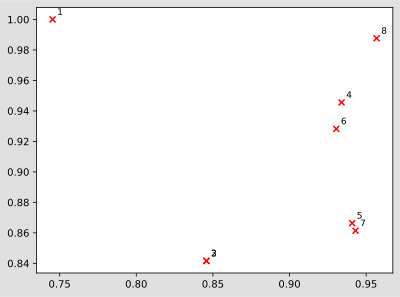

In [16]:
tme10.mapClassifiers({"1":tme10.APrioriClassifier(train),
                "2":tme10.ML2DClassifier(train,"exang"),
                "3":tme10.MAP2DClassifier(train,"exang"),
                "4":tme10.MAPNaiveBayesClassifier(train),
                "5":tme10.MLNaiveBayesClassifier(train),
                "6":tme10.ReducedMAPNaiveBayesClassifier(train,0.01),
                "7":tme10.ReducedMLNaiveBayesClassifier(train,0.01),
                "8":tme10.MAPTANClassifier(train),
               },train)

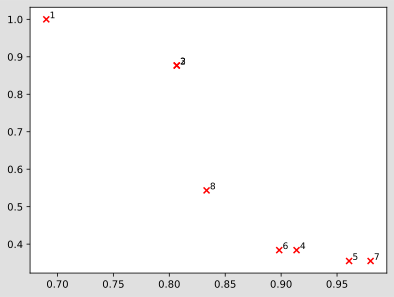

In [17]:
tme10.mapClassifiers({"1":tme10.APrioriClassifier(train),
                "2":tme10.ML2DClassifier(train,"exang"),
                "3":tme10.MAP2DClassifier(train,"exang"),
                "4":tme10.MAPNaiveBayesClassifier(train),
                "5":tme10.MLNaiveBayesClassifier(train),
                "6":tme10.ReducedMAPNaiveBayesClassifier(train,0.01),
                "7":tme10.ReducedMLNaiveBayesClassifier(train,0.01),
                "8":tme10.MAPTANClassifier(train),
               },test)

## 8- Conclusion finale

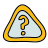
Quelle leçons & conclusion tirez-vous de ces expériences sur les classifieurs bayésiens ?